<a href="https://colab.research.google.com/github/GitGirlie27/urdu-ocr-codesaviours-si26-Amna/blob/main/SI26_Week4_Amna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *Install Packages*

In [1]:
!pip install opencv-python-headless pillow

# *Import Zip File*

In [2]:
import zipfile

zip_path = "/content/Urdu OCR Dataset Updated.zip"
extract_path = "/content/Urdu_OCR_Dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:

    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


# *Install Libraries*

In [3]:
import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
print('Libraries loaded successfully!')

Libraries loaded successfully!


# *Image Preprocessing Techniques*

In [4]:
def preprocess_image(image_path, save_path=None):
    # Read image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Could not load: {image_path}")
        return None

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Resize only if image height is very small
    h, w = gray.shape
    if h < 600:
        scale = 2
        gray = cv2.resize(
            gray,
            None,
            fx=scale,
            fy=scale,
            interpolation=cv2.INTER_CUBIC
        )

    # Contrast Enhancement (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)

    # Denoising (Using positional arguments to prevent OpenCV binding errors)
    denoised = cv2.fastNlMeansDenoising(enhanced, None, 12, 7, 21)

    # Adaptive Thresholding (Binarization)
    binary = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )

    # Morphological Opening to remove small artifacts/noise
    kernel = np.ones((2, 2), np.uint8)
    cleaned = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Save processed image if output path is specified
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        cv2.imwrite(save_path, cleaned)

    return cleaned

# *Process Entire Dataset*

In [5]:
import glob
input_folder = "/content/Urdu_OCR_Dataset/Urdu OCR Dataset"
output_folder = "/content/processed"

os.makedirs(output_folder, exist_ok=True)
image_paths = sorted(glob.glob(os.path.join(input_folder, "*.png")))

print(f"Total PNG images found: {len(image_paths)}")

for image_path in image_paths:
    filename = os.path.basename(image_path)
    save_path = os.path.join(output_folder, filename)
    preprocess_image(image_path, save_path)

print("Preprocessing completed successfully!")

Total PNG images found: 209
Preprocessing completed successfully!


# *Display Image Before and After Processing*

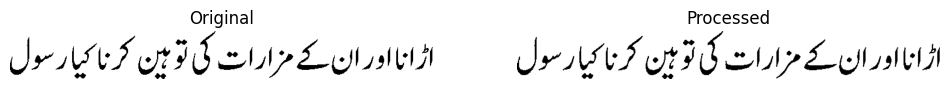

In [8]:
import cv2
import matplotlib.pyplot as plt

filename = os.path.basename(image_paths[200])

original = cv2.imread(f"/content/Urdu_OCR_Dataset/Urdu OCR Dataset/{filename}")
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

processed = cv2.imread(
    f"/content/processed/{filename}",
    cv2.IMREAD_GRAYSCALE
)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed, cmap="gray")
plt.title("Processed")
plt.axis("off")

plt.show()

# *Installing Tesseract Packages*

In [9]:
!apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 53 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 0s (21.4 MB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...


# *Create CSV File*

In [12]:
import os
import glob
import pandas as pd
import pytesseract
from PIL import Image

# 1. Directory path setup
image_folder = "/content/processed"
csv_output_path = "/content/labels.csv"

# 2. Get image paths safely
image_paths = sorted(
    glob.glob(os.path.join(image_folder, "*.png")),
    key=lambda x: int(os.path.splitext(os.path.basename(x))[0])
)
data = []

print(f"Found {len(image_paths)} images. Running Tesseract OCR...")

for image_path in image_paths:
    file_name = os.path.basename(image_path)

    try:
        # Open and verify image file integrity
        with Image.open(image_path) as img:
            img.verify()

        # Re-open for reading (Image.verify() closes the file handle)
        image = Image.open(image_path)

        # Perform OCR
        raw_text = pytesseract.image_to_string(
            image,
            lang="urd",
            config="--oem 3 --psm 6"
        )

        # Force string conversion and strip whitespace
        clean_text = str(raw_text).strip() if raw_text else ""

        # Filter out empty or whitespace-only OCR results
        if clean_text:
            data.append({
                "file_name": file_name,  # Store relative filename matching your dataset class
                "text": clean_text
            })
        else:
            print(f"Skipping empty OCR output for: {file_name}")

    except Exception as e:
        print(f"Error processing image {file_name}: {e}")

# 3. Create DataFrame
df = pd.DataFrame(data)

# 4. Strict Data Cleaning (Extra Safety layer against NaN/Nulls)
df.dropna(subset=['file_name', 'text'], inplace=True)
df['text'] = df['text'].astype(str).str.strip()
df = df[df['text'] != ""].reset_index(drop=True)

# 5. Save to CSV
df.to_csv(csv_output_path, index=False, encoding="utf-8-sig")

print(f"\nCSV created successfully! Saved {len(df)} valid records to '{csv_output_path}'.")

Found 219 images. Running Tesseract OCR...
Skipping empty OCR output for: 177.png

CSV created successfully! Saved 218 valid records to '/content/labels.csv'.


# *Check CSV File Created*

In [14]:
import pandas as pd

df = pd.read_csv("/content/Labels.csv", encoding="latin-1")

print(df.columns)

Index(['Image_no', 'Text'], dtype='object')


# *Build the Dataset Class*

In [37]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

class UrduOCRDataset(Dataset):
    def __init__(self, csv_file, processor, max_target_length=128):
        self.processor = processor
        self.max_target_length = max_target_length

        # Load CSV with encoding fix
        self.data = pd.read_csv(csv_file, encoding="latin-1")

        # Combine folder path with the 'Image_no' column from your CSV
        self.data["Full_Image_Path"] = self.data["Image_no"].apply(
            lambda x: os.path.join("/content/processed", str(x))
        )

        print(f"Dataset loaded successfully!")
        print(f"Total samples: {len(self.data)}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Open image using the full path we created
        image = Image.open(row["Full_Image_Path"]).convert("RGB")

        pixel_values = self.processor(
            image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        # Use 'Text' column matching your CSV casing
        text = str(row["Text"])

        labels = self.processor.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_target_length,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }

# *Install Packages*

In [16]:
!pip install -q transformers sentencepiece protobuf torch pillow pandas

# *Load Image Processor*

In [17]:
from transformers import TrOCRProcessor, RobertaTokenizer, ViTImageProcessor

# 1. Manually load the underlying tokenizer and image processor
# (This bypasses the broken auto-instantiation code completely)
tokenizer = RobertaTokenizer.from_pretrained(
    "microsoft/trocr-base-printed"
)
image_processor = ViTImageProcessor.from_pretrained('microsoft/trocr-base-printed')

# 2. Bundle them together into the TrOCRProcessor structure manually
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

print("Processor successfully loaded manually!")

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

Processor successfully loaded manually!


# *Test and Split Dataset*

In [38]:
import torch

# Create dataset (moved keyword argument 'encoding' to the end)
dataset = UrduOCRDataset('/content/Labels.csv', processor)

# Replace 'dataset' with whatever name you gave your Dataset object
sample = dataset[0]

print('Sample pixel_values shape:', sample['pixel_values'].shape)
print('Sample labels shape:', sample['labels'].shape)
print('Dataset is working correctly!')

# Create train / test split (80% train, 20% test)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)
print(f"Training samples: {train_size}")
print(f"Testing samples: {test_size}")

Dataset loaded successfully!
Total samples: 208
Sample pixel_values shape: torch.Size([3, 384, 384])
Sample labels shape: torch.Size([128])
Dataset is working correctly!
Training samples: 166
Testing samples: 42


# *Load Pretrained TrOCR Model*

In [39]:
from transformers import ViTImageProcessor, RobertaTokenizer, TrOCRProcessor, VisionEncoderDecoderModel
import torch

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# 1. Load the vision component safely
image_processor = ViTImageProcessor.from_pretrained('microsoft/trocr-base-printed')

# 2. Load a standard clean RoBERTa tokenizer (bypasses sentencepiece backend compilation)
tokenizer = RobertaTokenizer.from_pretrained('roberta-large')

# 3. Construct the TrOCRProcessor manually by pairing the independent components
processor = TrOCRProcessor(image_processor=image_processor, tokenizer=tokenizer)

# 4. Load the core model architecture
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed')
model = model.to(device)

# 5. Generation alignment configuration
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.sep_token_id

print('\n' + '='*50)
print('SUCCESS: Components assembled manually. The backend is completely bypassed!')
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print('='*50)

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


SUCCESS: Components assembled manually. The backend is completely bypassed!
Model parameters: 333,921,792


# Create Dataloader

In [40]:
from torch.utils.data import DataLoader
import torch

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(test_dataset, batch_size=4)

# Native PyTorch Optimizer (Clean and future-proof)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

print(f'Training batches per epoch: {len(train_loader)}')
print('Ready to train!')

Training batches per epoch: 42
Ready to train!


# *Set Up Training*

In [48]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    total_loss = 0
    correct_tokens = 0
    total_tokens = 0

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-"*50)

    for batch_idx, batch in enumerate(train_loader):

        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            pixel_values=pixel_values,
            labels=labels
        )

        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


        predictions = outputs.logits.argmax(dim=-1)

        mask = labels != -100

        correct_tokens += ((predictions == labels) & mask).sum().item()
        total_tokens += mask.sum().item()

        if batch_idx % 10 == 0:

            accuracy = 100 * correct_tokens / total_tokens

            print(
                f"Batch {batch_idx}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f} | "
                f"Accuracy: {accuracy:.2f}%"
            )

    avg_loss = total_loss / len(train_loader)
    epoch_accuracy = 100 * correct_tokens / total_tokens

    print("\nEpoch Summary")
    print(f"Average Loss : {avg_loss:.4f}")
    print(f"Accuracy     : {epoch_accuracy:.2f}%")


Epoch 1/5
--------------------------------------------------
Batch 0/42 | Loss: 1.7400 | Accuracy: 37.17%
Batch 10/42 | Loss: 1.5328 | Accuracy: 40.30%
Batch 20/42 | Loss: 1.4330 | Accuracy: 42.01%
Batch 30/42 | Loss: 1.3621 | Accuracy: 42.73%
Batch 40/42 | Loss: 1.3572 | Accuracy: 43.47%

Epoch Summary
Average Loss : 1.6119
Accuracy     : 43.50%

Epoch 2/5
--------------------------------------------------
Batch 0/42 | Loss: 1.3898 | Accuracy: 39.74%
Batch 10/42 | Loss: 1.6906 | Accuracy: 43.16%
Batch 20/42 | Loss: 2.1977 | Accuracy: 46.13%
Batch 30/42 | Loss: 1.5733 | Accuracy: 45.04%
Batch 40/42 | Loss: 1.4672 | Accuracy: 45.05%

Epoch Summary
Average Loss : 1.5594
Accuracy     : 45.18%

Epoch 3/5
--------------------------------------------------
Batch 0/42 | Loss: 1.3794 | Accuracy: 48.75%
Batch 10/42 | Loss: 1.9544 | Accuracy: 45.87%
Batch 20/42 | Loss: 1.5557 | Accuracy: 44.69%
Batch 30/42 | Loss: 1.1816 | Accuracy: 44.86%
Batch 40/42 | Loss: 1.6701 | Accuracy: 44.35%

Epoch Su

# Save Model

In [42]:
model.save_pretrained("/content/urdu_trocr_model")
processor.save_pretrained("/content/urdu_trocr_model")

print("Model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


In [44]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 88.1 MB/s eta 0:00:00
